### Import Libraries

In [2]:
%pip install pandas matplotlib seaborn polars pyarrow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries

In [6]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

### Load Dataset

In [7]:
df = pl.read_csv("Churn_Modelling.csv")

df.head()

RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
i64,i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64
1,15634602,"""Hargrave""",619,"""France""","""Female""",42,2,0.0,1,1,1,101348.88,1
2,15647311,"""Hill""",608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58,0
3,15619304,"""Onio""",502,"""France""","""Female""",42,8,159660.8,3,1,0,113931.57,1
4,15701354,"""Boni""",699,"""France""","""Female""",39,1,0.0,2,0,0,93826.63,0
5,15737888,"""Mitchell""",850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1,0


### Dataset Understanding

Shape

In [8]:
df.shape

(10000, 14)

The dataset contains 10,000 customer records and 14 columns.

Each row represents a unique customer and each column represents a customer attribute.

### Missing Values

In [13]:
df.null_count()

RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Observation:
No missing values were found in any column.

Business Impact:
The dataset is complete and reliable for analysis.

Recommendation:
No missing value treatment was required.

### Duplicate Records

In [14]:
duplicates = df.height - df.unique().height

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Observation
No duplicate records were found in the dataset.

Business Impact:
Customer counts and churn calculations are accurate and not inflated by duplicate entries.

Recommendation:
No duplicate removal was required.

In [16]:
(
    df.group_by("Exited")
      .len()
      .sort("Exited")
)

Exited,len
i64,u32
0,7963
1,2037


### Churn Percentage

In [18]:
churn_pct = (
    df.group_by("Exited")
      .len()
      .with_columns(
          (pl.col("len") * 100 / pl.col("len").sum())
          .round(2)
          .alias("Percentage")
      )
      .sort("Exited")
)

churn_pct

Exited,len,Percentage
i64,u32,f64
0,7963,79.63
1,2037,20.37


Visualisation

In [ ]:
%pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/28.0 MB ? eta -:--:--
   -- ------------------------------------- 2.1/28.0 MB 6.7 MB/s eta 0:00:04
   ---- ----------------------------------- 3.4/28.0 MB 6.2 MB/s eta 0:00:04
   ------ --------------------------------- 4.7/28.0 MB 7.7 MB/s eta 0:00:04
   --------- ------------------------------ 6.6/28.0 MB 6.8 MB/s eta 0:00:04
   ---------- ----------------------------- 7.1/28.0 MB 6.7 MB/s eta 0:00:04
   ------------ --------------------------- 8.9/28.0 MB 6.4 MB/s eta 0:00:03
   -------------- ------------------------- 10.2/28.0 MB 6.3 MB/s eta 0:00:03
   --------------- ------------------------ 11.0/28.0 MB 5.8 MB/s eta 0:00:03
   ---------------- ----------------------- 11.5/28.0 MB 5.4 MB/s eta 0:00:04
   -------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


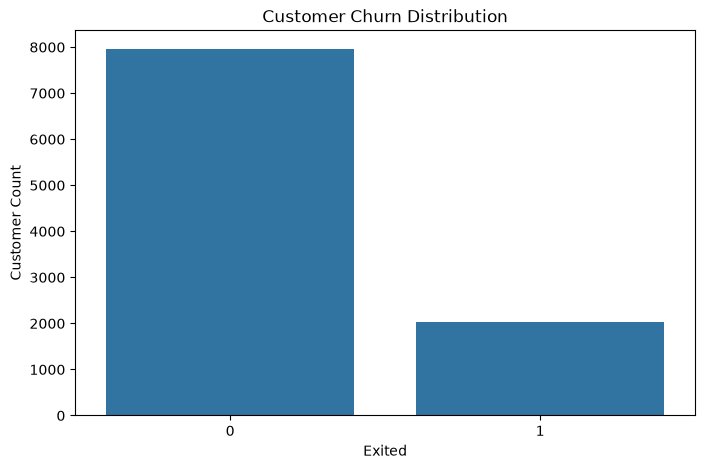

In [21]:
sns.countplot(
    x=df["Exited"].to_pandas()
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Customer Count")
plt.show()

### Case Study Insight #1

Observation

20.37% customers have left the bank while 79.63% customers remained active.

Possible Reason

Customers may be dissatisfied with services, pricing, customer support, or may have received better offers from competing banks.

Business Impact

Losing approximately 1 out of every 5 customers can significantly reduce revenue, customer lifetime value, and future growth opportunities.

Recommendation

The bank should identify high-risk customer segments and implement retention strategies such as loyalty rewards, personalized offers, and proactive customer engagement.

Geography vs Churn

In [23]:
geo_churn = (
    df.group_by("Geography")
      .agg(
          pl.len().alias("Customers"),
          pl.sum("Exited").alias("Churned"),
          (pl.mean("Exited") * 100)
              .round(2)
              .alias("ChurnRate")
      )
      .sort("ChurnRate", descending=True)
)

geo_churn

Geography,Customers,Churned,ChurnRate
str,u32,i64,f64
"""Germany""",2509,814,32.44
"""Spain""",2477,413,16.67
"""France""",5014,810,16.15


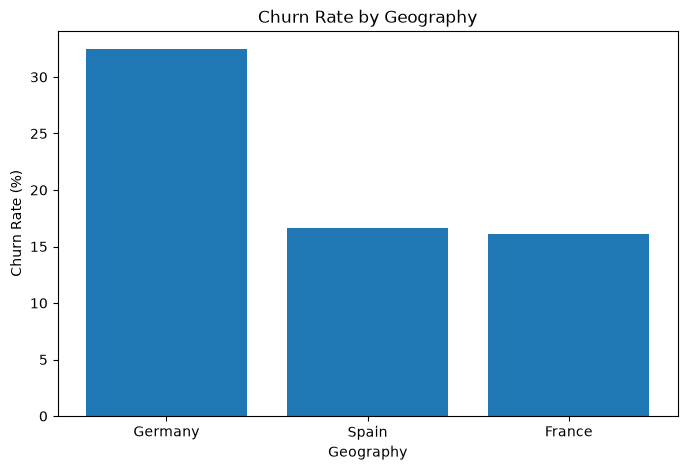

In [45]:
plt.figure(figsize=(8,5))

plt.bar(
    geo_churn["Geography"],
    geo_churn["ChurnRate"]
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.show()

### Case Study Insight #2

Observation

Germany has the highest churn rate (32.44%), which is almost double the churn rate of France (16.15%) and Spain (16.67%).

Possible Reason

Customers in Germany may be facing:

Higher competition from other banks
Lower satisfaction levels
Different customer expectations
Pricing or service-related issues
Business Impact

Germany contributes a disproportionately large share of customer losses despite having fewer customers than France.

Recommendation

The bank should:

Conduct customer satisfaction surveys in Germany
Investigate complaints and service quality
Launch targeted retention campaigns for German customers
Offer loyalty benefits and personalized banking services

### Gender vs Churn

In [46]:
gender_churn = (
    df.group_by("Gender")
      .agg([
          pl.len().alias("Customers"),
          pl.sum("Exited").alias("Churned"),
          (
              pl.mean("Exited") * 100
          ).round(2).alias("ChurnRate")
      ])
      .sort("ChurnRate", descending=True)
)

gender_churn

Gender,Customers,Churned,ChurnRate
str,u32,i64,f64
"""Female""",4543,1139,25.07
"""Male""",5457,898,16.46


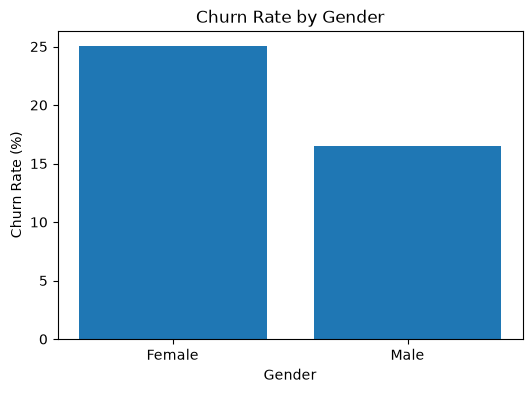

In [47]:
plt.figure(figsize=(6,4))

plt.bar(
    gender_churn["Gender"],
    gender_churn["ChurnRate"]
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

### Observation
Female customers have a higher churn rate (25.07%) than male customers (16.46%).

Business Impact: 
More than half of churned customers are female, indicating a high-risk customer segment.

Recommendation:
Analyze customer feedback and introduce targeted retention strategies for female customers.

### Case Study Insight #3
Observation

Female customers have a churn rate of 25.07%, while male customers have a churn rate of 16.46%.

Possible Reason

Female customers may have different expectations regarding banking services, products, or customer support.

Business Impact

A large proportion of churned customers are female, making this an important segment for retention efforts.

Recommendation

Develop targeted engagement strategies and investigate customer satisfaction patterns among female customers.

### Age vs Churn Analysis

In [48]:
age_churn = (
    df.group_by("Exited")
      .agg([
          pl.mean("Age").round(2).alias("AverageAge"),
          pl.median("Age").alias("MedianAge")
      ])
)

age_churn

Exited,AverageAge,MedianAge
i64,f64,f64
0,37.41,36.0
1,44.84,45.0


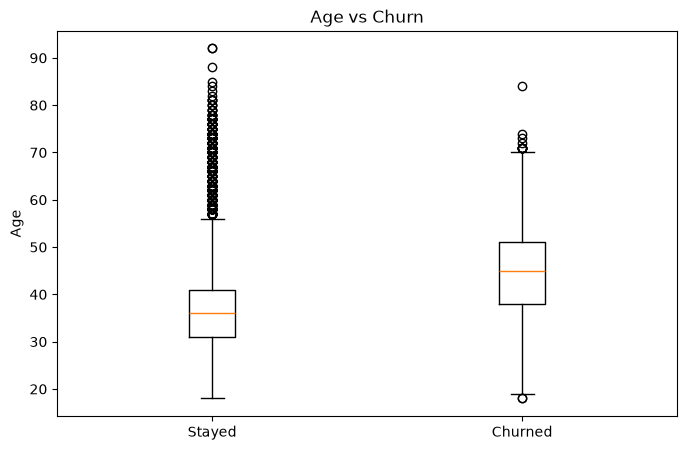

In [62]:
plt.figure(figsize=(8,5))

plt.boxplot([
    df.filter(pl.col("Exited") == 0)["Age"],
    df.filter(pl.col("Exited") == 1)["Age"]
])

plt.xticks([1,2], ["Stayed", "Churned"])

plt.title("Age vs Churn")
plt.ylabel("Age")

plt.show()

In [54]:
df.select(
    pl.col("Age")
).describe()

statistic,Age
str,f64
"""count""",10000.0
"""null_count""",0.0
"""mean""",38.9218
"""std""",10.487806
"""min""",18.0
"""25%""",32.0
"""50%""",37.0
"""75%""",44.0
"""max""",92.0


Observation:

Customers who churned are older on average (44.84 years) compared to retained customers (37.41 years).
The average age difference is 7.43 years, indicating that age may be a strong factor influencing customer churn.
Older customers appear more likely to leave the bank than younger customers.

Business Insight:

Age is a potentially important predictor of churn and should be considered in customer retention strategies

### Case Study Insight #4
Observation

Customers who left the bank had an average age of 44.84 years, compared to 37.41 years for customers who stayed.

Possible Reason

Older customers may have different expectations and banking requirements.

Business Impact

Age is a strong predictor of customer churn and should be monitored carefully.

Recommendation

Implement targeted retention strategies for older customers.

In [55]:
active_churn = (
    df.group_by("IsActiveMember")
      .agg([
          pl.len().alias("Customers"),
          pl.sum("Exited").alias("Churned"),
          (
              pl.mean("Exited") * 100
          ).round(2).alias("ChurnRate")
      ])
      .sort("ChurnRate", descending=True)
)

active_churn

IsActiveMember,Customers,Churned,ChurnRate
i64,u32,i64,f64
0,4849,1302,26.85
1,5151,735,14.27


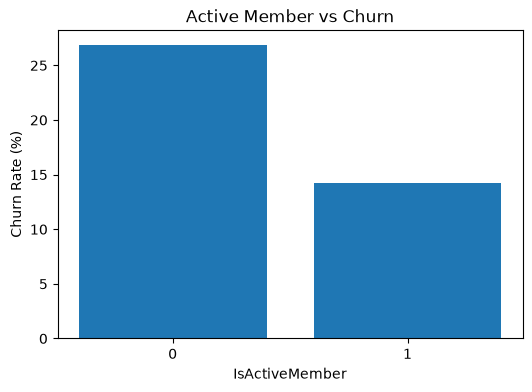

In [56]:
plt.figure(figsize=(6,4))

plt.bar(
    active_churn["IsActiveMember"].cast(str),
    active_churn["ChurnRate"]
)

plt.title("Active Member vs Churn")
plt.xlabel("IsActiveMember")
plt.ylabel("Churn Rate (%)")

plt.show()

Observation:

Inactive customers have a significantly higher churn rate (26.85%) compared to active customers (14.27%).
The churn rate difference of 12.58% indicates that customer activity is strongly associated with retention.
This suggests that inactive customers are much more likely to leave the bank, making customer engagement an important factor in reducing churn.

### Product vs churn

In [57]:
product_churn = (
    df.group_by("NumOfProducts")
      .agg([
          pl.len().alias("Customers"),
          pl.sum("Exited").alias("Churned"),
          (
              pl.mean("Exited") * 100
          ).round(2).alias("ChurnRate")
      ])
      .sort("NumOfProducts")
)

product_churn

NumOfProducts,Customers,Churned,ChurnRate
i64,u32,i64,f64
1,5084,1409,27.71
2,4590,348,7.58
3,266,220,82.71
4,60,60,100.0


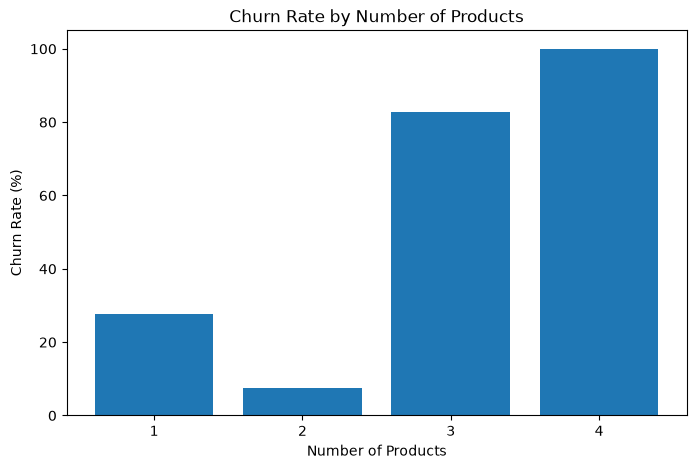

In [58]:
plt.figure(figsize=(8,5))

plt.bar(
    product_churn["NumOfProducts"].cast(str),
    product_churn["ChurnRate"]
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

Observation:

Customers with 2 products have the lowest churn rate (7.58%), making them the most loyal segment.
Customers with 1 product show a much higher churn rate (27.71%).
Customers with 3–4 products have extremely high churn rates (82.71% and 100%), though the number of customers in these groups is relatively small.
This suggests that the relationship between the number of products and churn is non-linear and warrants further investigation. 📊

Business Insight:

Having 2 products appears to improve customer retention, while customers with 3–4 products may face issues related to product complexity, fees, or service satisfaction.

### Case Study Insight #6
Observation

Customers holding 2 products have the lowest churn rate (7.58%).

Customers holding 3 or 4 products exhibit extremely high churn rates (82.71% and 100% respectively).

Possible Reason

Customers with excessive product holdings may experience higher costs, complexity, or unmet expectations.

Business Impact

Premium and multi-product customers may represent a hidden churn risk despite their higher value.

Recommendation

Investigate customers with 3+ products and review pricing, bundling strategies, and service quality

### Balance vs Churn

In [59]:
balance_churn = (
    df.group_by("Exited")
      .agg([
          pl.mean("Balance").round(2).alias("AvgBalance"),
          pl.median("Balance").alias("MedianBalance")
      ])
)

balance_churn

Exited,AvgBalance,MedianBalance
i64,f64,f64
0,72745.3,92072.68
1,91108.54,109349.29


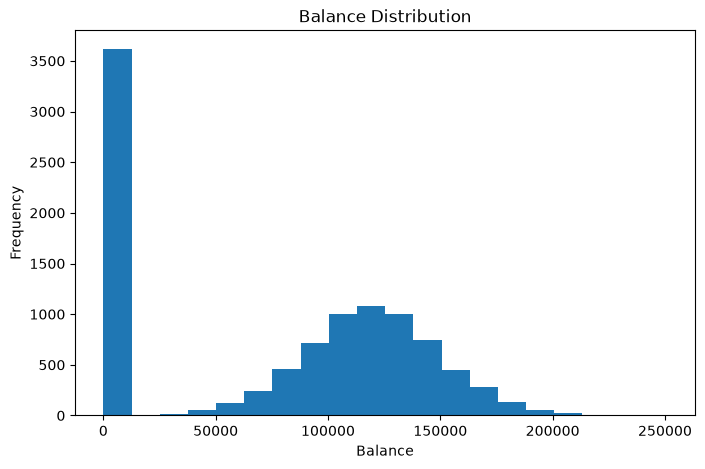

In [61]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Balance"],
    bins=20
)

plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

Observation:
Customers who churned had a higher average balance (91,108) than customers who stayed (72,745).

Business Insight:
The bank is losing high-value customers, which can significantly impact revenue.

### Credit vs Churn

In [60]:
credit_churn = (
    df.group_by("Exited")
      .agg([
          pl.mean("CreditScore").round(2).alias("AvgCreditScore")
      ])
)

credit_churn

Exited,AvgCreditScore
i64,f64
0,651.85
1,645.35


Observation:
The average credit score difference between churned (645.35) and retained (651.85) customers is very small.

Business Insight:
Credit score has a weak relationship with churn and is not a major churn driver in this dataset.

### Conclusion

The Customer Churn Analysis was conducted on a dataset containing 10,000 banking customers. Data quality checks confirmed that the dataset contained no missing values and no duplicate records, making it suitable for analysis.

The overall churn rate was 20.37%, indicating that approximately one out of every five customers had left the bank.

Key findings include:

Germany exhibited the highest churn rate (32.44%).
Female customers had a higher churn rate (25.07%) than male customers (16.46%).
Customers who churned were significantly older, with an average age of 44.84 years compared to 37.41 years for retained customers.
Inactive customers experienced nearly double the churn rate (26.85%) of active customers (14.27%).
Customers with 2 products showed the lowest churn rate (7.58%), while customers with 3–4 products displayed extremely high churn rates.
Customers who churned maintained higher average balances, indicating that the bank may be losing valuable customers.
Credit score showed only a weak relationship with churn.
Recommendations
Focus retention efforts on inactive customers.
Investigate the unusually high churn among customers with 3+ products.
Develop targeted strategies for older customers.
Improve customer retention programs in Germany.
Create premium engagement programs for high-balance customers.

In [64]:
numeric_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]

corr_matrix = {
    col1: [
        df.select(pl.corr(col1, col2)).item()
        for col2 in numeric_cols
    ]
    for col1 in numeric_cols
}

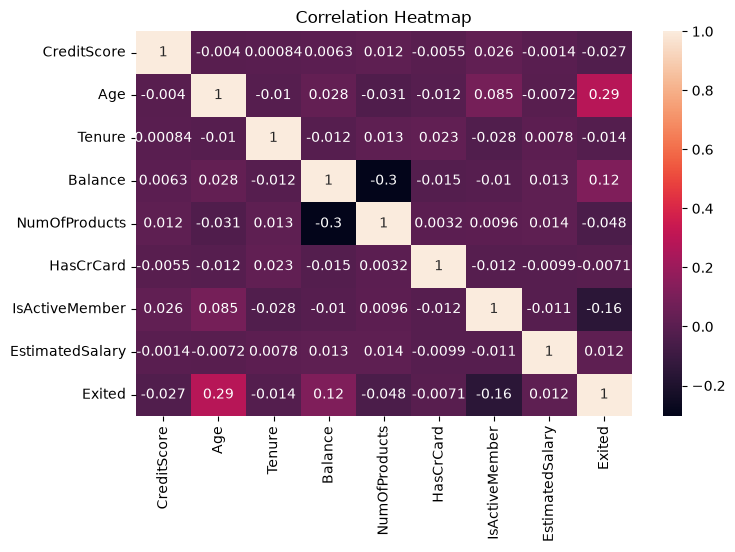

In [65]:
import pandas as pd

corr_df = pd.DataFrame(
    corr_matrix,
    index=numeric_cols
)

sns.heatmap(
    corr_df,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()